In [1]:
from notebook_env import *
import glob
import os
import ast
import evoml.analysis
import evoml.dynamics
import zipfile

import scipy.interpolate

## CIFAR

<Axes: xlabel='p'>

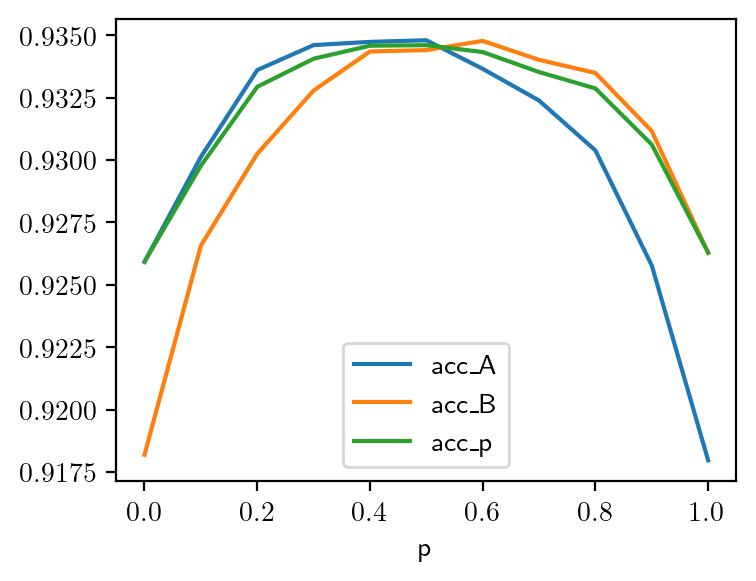

In [2]:
dcts = ast.literal_eval(open('./data/cifar10_augmentations.repr','r').read())

cifar_augmentations_game_df = (
    pd.DataFrame(dcts)
    .transpose()
    .rename({
        ('test',False): 'acc_A',
        ('test',True): 'acc_B',
    },axis=1)
    .assign(
        p=lambda df: df['config'].map(lambda d: float(d[('training','flip_prob')])),
        acc_p=lambda df: (1-df['p'])*df['acc_A'] + df['p']*df['acc_B'],
    )
    .set_index('p')
    [['acc_A','acc_B','acc_p']]
    .sort_index()
)

cifar_augmentations_game_df.groupby(level=0).mean().plot.line(figsize=(4,3))

In [3]:
param(
    cifar_augmentations_game_df.loc[0,'acc_A'].mean(),
    'cifar_augmentation_single_group_accuracy',
    '{:.1%}',
)
param(
    cifar_augmentations_game_df.loc[0.5,'acc_A'].mean(),
    'cifar_augmentation_coexistence_accuracy',
    '{:.1%}',
)
param(
    cifar_augmentations_game_df.loc[0,'acc_A'].count(),
    'cifar_augmentation_n_repetitions',
)

cifar_augmentation_single_group_accuracy=92.6%
cifar_augmentation_coexistence_accuracy=93.5%
cifar_augmentation_n_repetitions=20


20

In [4]:
class InterpolatedFitness:
    def __init__(self, game_df, sample=True, interpolation_kind='linear'):
        self.game_df = game_df
        self.sample = sample
        self.interpolation_kind = interpolation_kind
        x = self.game_df.groupby(level=0).mean().index.to_numpy()
        agg = (lambda dfg: dfg.sample(1)) if self.sample else (lambda dfg: dfg.mean())
        a = self.game_df['acc_A'].groupby(level=0).pipe(agg).to_numpy()
        b = self.game_df['acc_B'].groupby(level=0).pipe(agg).to_numpy()
        interp = lambda y: scipy.interpolate.interp1d(
            x=x,
            y=y,
            kind=self.interpolation_kind,
        )
        self.interp_a = interp(a)
        self.interp_b = interp(b)

    def __call__(self, p):
        assert len(p)==2, 'Interpolation is implemented in two-group settings'
        pb = p[-1]
        return np.array([self.interp_a(pb), self.interp_b(pb)])

class ReflectedFitness:
    def __init__(self, fitness, p_eq):
        self.fitness = fitness
        self.p_eq = np.array(p_eq)

    def __call__(self, p):
        return self.fitness(2*self.p_eq - p)
        

fitness = InterpolatedFitness(
    game_df=cifar_augmentations_game_df.groupby(level=0).mean(),
)
fitness([0.5,0.5])

array([0.9348  , 0.934405])

In [5]:
T = 2000
p0 = 0.2
res1 = evoml.dynamics.discrete_replicator(
    p0=[1-p0,p0],
    fitness=fitness,
    T=T,
    return_welfare=True,
)
res2 = evoml.dynamics.discrete_replicator(
    p0=[1-p0,p0],
    fitness=ReflectedFitness(fitness, p_eq=(0.5,0.5)),
    T=T,
    return_welfare=True,
)

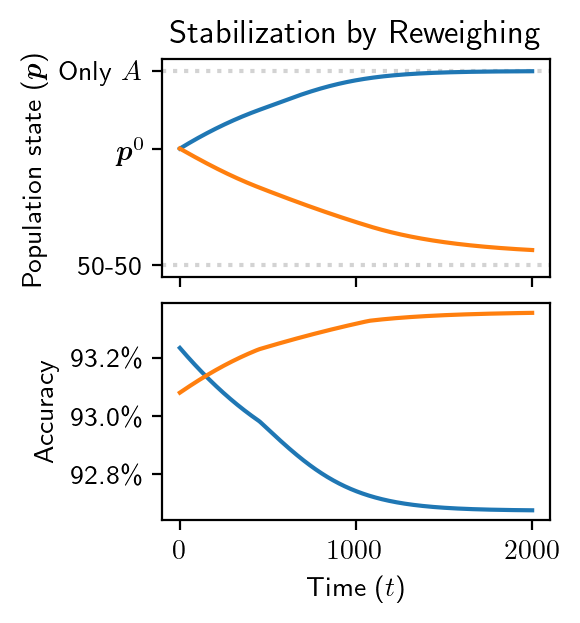

In [6]:
fig,axs=evoml.create_figure(2,1,figsize=(3,3))
ax = axs[0]
ax.plot(
    res1[0][:,0],
    # label='Unstabilized',
    label='$\\mathcal{A}(\\bm{p})$',
)
ax.plot(
    res2[0][:,0],
    # label='Stabilized',
    label='$\\mathcal{A}\'(\\bm{p})$',
)

ax.set(
    title='Stabilization by Reweighing', #  $F_k(\\bm{p})$
    ylabel=evoml.analysis.composition_label,
    yticks=evoml.analysis.composition_tickpos + [1-p0],
    yticklabels=evoml.analysis.composition_ticklabels + ['$\\bm{p}^0$'],
    # ylim=(-0.03,1.03),
    ylim=(0.5-0.03,1+0.03),
)
ax.set(
    xticklabels=[],
    # yticklabels=[],
)
ax.axhline(0.5,**evoml.background_line_style)
ax.axhline(1,**evoml.background_line_style)
ax.axhline(0.0,**evoml.background_line_style)
# ax.legend()

ax=axs[1]
ax.plot(res1[1])
ax.plot(res2[1])
ax.set(
    ylabel='Accuracy',
    xlabel='Time ($t$)',
)
ax.yaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(xmax=1,decimals=1),
)

## MNIST

In [7]:
extract_p = lambda path: (
    int(os.path.basename(path).split('.')[0].split('_')[1])
    /int(os.path.basename(path).split('.')[0].split('_')[2])
)

zf = zipfile.ZipFile('./data/mnist_label_noise.zip')
results = []
for f in zf.filelist:
    path = f.filename
    for dct in json.load(zf.open(f)):
        results.append({
            'filename': os.path.basename(path),
            'p': extract_p(path=path),
            'epoch': dct['epoch'],
        } | {
            f'{k}_{suffix}': v
            for group, suffix in [('group_a','A'), ('group_b','B'), ('training_set','train')]
            for k,v in dct[group].items()
        })

mnist_df = pd.DataFrame(results)
selected_epoch = 200

In [8]:
mnist_game_df = (
    mnist_df
    .query('epoch==@selected_epoch')
    .assign(acc_p=lambda df: df['acc_A']*(1-df['p']) + df['acc_B']*df['p'])
    .groupby('p')
    [['acc_A','acc_B','acc_p']]
    .mean()
    # .iloc[1::2]
)
mnist_game_df.loc[:0.6]

,acc_A,acc_B,acc_p
p,,,
0.0,0.801125,0.811083,0.801125
0.1,0.801996,0.807925,0.802589
0.2,0.800528,0.807234,0.801869
0.3,0.803254,0.805254,0.803854
0.4,0.802266,0.804365,0.803106
0.5,0.804024,0.803595,0.803810
0.6,0.806020,0.801155,0.803101


In [9]:
param(
    mnist_df.query('epoch==@selected_epoch')['acc_train'].mean(),
    'mnist_label_noise_train_accuracy',
    '{:.1%}',
)

param(
    mnist_df.query('epoch==@selected_epoch and p==0.5')['acc_A'].mean(),
    'mnist_label_noise_coexistence_accuracy',
    '{:.1%}',
)

mnist_label_noise_train_accuracy=98.7%
mnist_label_noise_coexistence_accuracy=80.4%


0.804024193548387

## Summary

Figure saved as ./output/empirical.pdf


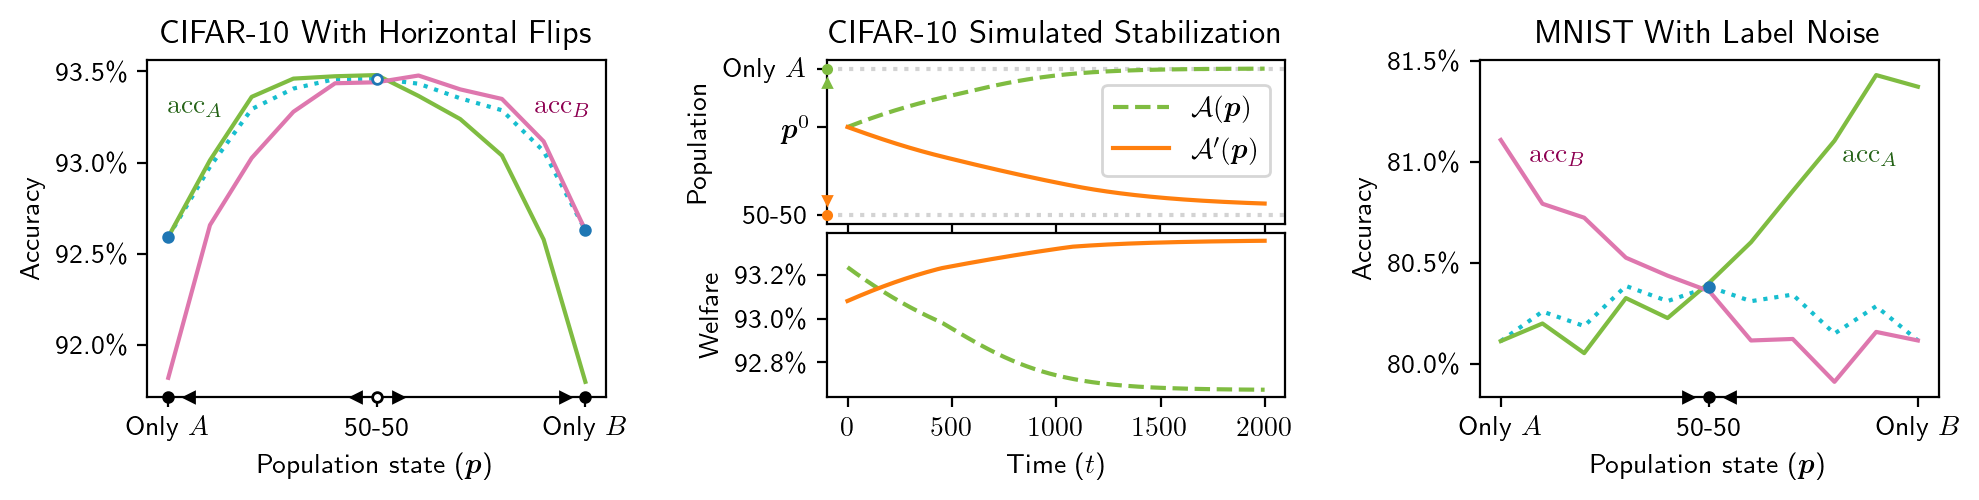

In [10]:
fig,axs = plt.subplot_mosaic(
    mosaic=[['cifar','stab1','mnist'],['cifar','stab2','mnist']],
    figsize=(10,2.3),
    constrained_layout=dict(
        w_pad=0.15,
        hspace=0.0,
        h_pad=0.0,
    ),
)

ax = axs['cifar']
evoml.plot_population_game(
    cifar_augmentations_game_df.groupby(level=0).mean(),
    ax=ax,
    equilibria=[
        (0,True),
        (0.5,False),
        (1,True),
    ],
    annotations={
        'acc_A': (0.0,0.9327),
        'acc_B': (0.88,0.9327),
    },
)
ax.set(
    title='CIFAR-10 With Horizontal Flips',
)

ax = axs['mnist']
evoml.plot_population_game(
    mnist_game_df,
    ax=ax,
    equilibria=[
        (0.5,True),
    ],
    annotations={
        'acc_A': (0.82,0.81),
        'acc_B': (0.07,0.81),
    },
)
ax.set(
    title='MNIST With Label Noise',
)


ax = axs['stab1']
label1='$\\mathcal{A}(\\bm{p})$'
label2='$\\mathcal{A}\'(\\bm{p})$'
c1=evoml.analysis.group_colors[0]
c2='tab:orange'
ax.plot(
    res1[0][:,0],
    label=label1,
    color=c1,
    linestyle='--',
    
)
ax.plot(
    res2[0][:,0],
    label=label2,
    color=c2,
)

ax.set(
    title='CIFAR-10 Simulated Stabilization', #  $F_k(\\bm{p})$
    ylabel='Population',
    yticks=evoml.analysis.composition_tickpos + [1-p0],
    yticklabels=evoml.analysis.composition_ticklabels + ['$\\bm{p}^0$'],
    ylim=(0.5-0.03,1+0.03),
)
ax.set(
    xticklabels=[],
)
ax.axhline(0.5,**evoml.background_line_style)
ax.axhline(1,**evoml.background_line_style)
ax.axhline(0.0,**evoml.background_line_style)
ax.legend(loc=(0.6,0.29))

with evoml.analysis.autoscale_turned_off(ax=ax):
    x = ax.get_xlim()[0]
    for y,c,m in [
        (1.0, c1, 'o'),
        (0.95, c1, '^'),
        (0.55, c2, 'v'),
        (0.5, c2, 'o'),
    ]:
        ax.plot(
            x,y,
            marker=m,
            clip_on=False,
            zorder=100,
            color=c,
            markersize=3,
        )

ax = axs['stab2']
ax.plot(res1[1], color=c1, linestyle='--', label=label1)
ax.plot(res2[1], color=c2, label=label2)
ax.set(
    ylabel='Welfare',
    xlabel='Time ($t$)',
)
ax.yaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(xmax=1,decimals=1),
)

evoml.analysis.save_and_download_fig(fig, './output/empirical.pdf', bbox_inches='tight')


In [11]:
param_tracker.save('./output/empirical.json')

Parameters saved as: ./output/empirical.json
